In [1]:
import os
import gzip
import random
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [2]:
# ====================== 全局配置 ======================
NOTEBOOK_DIR = Path('/Users/chris/Desktop')
DATA_ROOT = NOTEBOOK_DIR / 'BRAINMETASTASIS'
DATA_URL = None
DOWNLOAD_DIR = NOTEBOOK_DIR / 'datasets'
TRAIN_ROOT = DATA_ROOT / 'train'
TEST_ROOT = DATA_ROOT / 'test'
IMG_SIZE = (64, 64, 64)
LATENT_CHANNEL = 4
T_DIFFUSION = 200
VAE_EPOCHS = 3
LDM_EPOCHS = 5
BATCH_SIZE = 1
TRAIN_AUGMENTATIONS = 4
EVAL_SAMPLES = 16
DENOISE_STRENGTH = 0.35
SHARPEN_STRENGTH = 0.24
LESION_EXPOSURE_REDUCTION = 0.22
MAX_GENERATED_CHANGE = 0.08

if not TRAIN_ROOT.exists() or not TEST_ROOT.exists():
    raise FileNotFoundError(f'需要同时存在训练目录和测试目录: {TRAIN_ROOT}, {TEST_ROOT}')

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'运行设备: {device}')
print(f'训练目录: {TRAIN_ROOT}')
print(f'测试目录: {TEST_ROOT}')
print(f'训练增强倍数: {TRAIN_AUGMENTATIONS} | 随机测试切片评估数: {EVAL_SAMPLES}')
print(f'去噪强度: {DENOISE_STRENGTH} | 纹理增强: {SHARPEN_STRENGTH} | 病变曝光降低: {LESION_EXPOSURE_REDUCTION}')

运行设备: mps
训练目录: /Users/chris/Desktop/BRAINMETASTASIS/train
测试目录: /Users/chris/Desktop/BRAINMETASTASIS/test
训练增强倍数: 4 | 随机测试切片评估数: 16
去噪强度: 0.35 | 纹理增强: 0.24 | 病变曝光降低: 0.22


In [3]:
# ====================== 1. 2D切片数据集：按病例堆叠为3D MRI ======================
from PIL import Image



def _slice_number(path):
    stem = path.stem.lower()
    if '_z' in stem:
        return int(stem.rsplit('_z', 1)[-1])
    return 0



def _case_dirs(root_dir):
    root = Path(root_dir).expanduser()
    return sorted(path for path in root.glob('Mets_*') if path.is_dir())



def _load_png_volume(case_dir, modality='t1_gd'):
    slice_dir = case_dir / modality
    files = sorted(slice_dir.glob('*.png'), key=_slice_number)
    if not files:
        raise ValueError(f'病例缺少 {modality} PNG 切片: {case_dir}')
    slices = []
    for path in files:
        image = Image.open(path).convert('L')
        image = image.resize((IMG_SIZE[1], IMG_SIZE[0]), Image.Resampling.BILINEAR)
        slices.append(np.asarray(image, dtype=np.float32) / 255.0)
    volume = np.stack(slices, axis=0)
    volume = torch.from_numpy(volume).unsqueeze(0).unsqueeze(0)
    volume = F.interpolate(volume, size=IMG_SIZE, mode='trilinear', align_corners=False)
    return volume.squeeze(0)



def _augment_training_volume(volume):
    volume = volume.clone()
    for axis in (1, 2, 3):
        if random.random() < 0.5:
            volume = torch.flip(volume, dims=(axis,))
    scale = random.uniform(0.96, 1.04)
    offset = random.uniform(-0.02, 0.02)
    noise = torch.randn_like(volume) * 0.005
    return (volume * scale + offset + noise).clamp(0, 1)



def validate_brainmets_dataset(root_dir=DATA_ROOT):
    root = Path(root_dir).expanduser()
    cases = _case_dirs(root / 'train') if (root / 'train').exists() else _case_dirs(root)
    if not cases:
        raise FileNotFoundError(f'没有找到 Mets_* 病例目录: {root}')
    valid, invalid = [], []
    for case_dir in cases:
        try:
            volume = _load_png_volume(case_dir)
            if tuple(volume.shape) != (1, *IMG_SIZE) or not torch.isfinite(volume).all():
                raise ValueError(f'体数据形状异常: {tuple(volume.shape)}')
            valid.append(case_dir)
        except Exception as exc:
            invalid.append(f'{case_dir}: {exc}')
    print(f'数据目录: {root}')
    print(f'病例数: {len(cases)} | 可用: {len(valid)} | 异常: {len(invalid)}')
    print(f'输入模态: t1_gd | 统一体数据尺寸: {IMG_SIZE}')
    print('seg 标签存在，但当前模型是无监督重建/生成模型，不直接计算 Dice。')
    if invalid:
        print('异常病例示例:', invalid[:3])
    return {'root': root, 'cases': valid, 'invalid_cases': invalid}



class BrainMets3DDataset(Dataset):
    def __init__(self, root_dir, modality='t1_gd', samples_per_case=1, augment=False):
        self.root = Path(root_dir).expanduser()
        self.modality = modality
        self.cases = _case_dirs(self.root)
        self.samples_per_case = max(1, int(samples_per_case))
        self.augment = augment
        if not self.cases:
            raise ValueError(f'{self.root} 中没有 Mets_* 病例目录')
        self.files = self.cases
        print(
            f'数据目录: {self.root} | 病例数: {len(self.cases)} | '
            f'采样数: {len(self)} | 模态: {modality} | 增强: {augment}'
        )

    def __len__(self):
        return len(self.cases) * self.samples_per_case

    def __getitem__(self, idx):
        case = self.cases[idx % len(self.cases)]
        volume = _load_png_volume(case, self.modality)
        return _augment_training_volume(volume) if self.augment else volume

In [4]:
# ====================== 0.1 数据集下载与解压 ======================
import shutil
import tarfile
import urllib.request
import zipfile


def download_brain_dataset(data_url=DATA_URL, download_dir=DOWNLOAD_DIR, extract_dir=None):
    """下载并解压 BrainMets/BraTS 类数据；需要用户提供有权限的下载直链。"""
    if not data_url:
        raise ValueError(
            '请先设置 DATA_URL。BrainMets 等医学影像数据通常需要登录/授权，'
            '不能在 notebook 中内置公开下载地址。'
        )

    download_dir = Path(download_dir).expanduser()
    download_dir.mkdir(parents=True, exist_ok=True)
    archive_name = Path(urllib.request.urlparse(data_url).path).name or 'brain_dataset.download'
    archive_path = download_dir / archive_name
    extract_dir = Path(extract_dir or download_dir / 'brain_dataset').expanduser()
    extract_dir.mkdir(parents=True, exist_ok=True)

    if not archive_path.exists():
        print(f'开始下载: {data_url}')
        urllib.request.urlretrieve(data_url, archive_path)
        print(f'下载完成: {archive_path}')
    else:
        print(f'复用已有压缩包: {archive_path}')

    marker = extract_dir / '.extracted'
    if not marker.exists():
        print(f'开始解压到: {extract_dir}')
        if zipfile.is_zipfile(archive_path):
            with zipfile.ZipFile(archive_path) as archive:
                archive.extractall(extract_dir)
        elif tarfile.is_tarfile(archive_path):
            with tarfile.open(archive_path) as archive:
                archive.extractall(extract_dir)
        elif archive_path.suffix.lower() == '.gz':
            output_path = extract_dir / archive_path.stem
            with gzip.open(archive_path, 'rb') as source, output_path.open('wb') as target:
                shutil.copyfileobj(source, target)
        else:
            raise ValueError(f'不支持的压缩格式: {archive_path.suffix}')
        marker.touch()
    else:
        print(f'复用已解压数据: {extract_dir}')

    return extract_dir


# 使用示例：
# DATA_URL = '你的 BrainMets/BraTS 授权下载直链'
# DATA_ROOT = download_brain_dataset()
# dataset_report = validate_brainmets_dataset(DATA_ROOT)

In [5]:
# ====================== 1.1 数据集体检与训练/测试确认 ======================
train_report = validate_brainmets_dataset(DATA_ROOT / 'train')
test_report = validate_brainmets_dataset(DATA_ROOT / 'test')
print(f"训练病例: {len(train_report['cases'])} | 测试病例: {len(test_report['cases'])}")

# 确认数据无异常后执行短训练，并在 test 上评估重建误差。
# 训练函数定义完成后再执行 train(TRAIN_ROOT, TEST_ROOT)。

数据目录: /Users/chris/Desktop/BRAINMETASTASIS/train
病例数: 105 | 可用: 105 | 异常: 0
输入模态: t1_gd | 统一体数据尺寸: (64, 64, 64)
seg 标签存在，但当前模型是无监督重建/生成模型，不直接计算 Dice。
数据目录: /Users/chris/Desktop/BRAINMETASTASIS/test
病例数: 51 | 可用: 51 | 异常: 0
输入模态: t1_gd | 统一体数据尺寸: (64, 64, 64)
seg 标签存在，但当前模型是无监督重建/生成模型，不直接计算 Dice。
训练病例: 105 | 测试病例: 51


In [6]:
# ====================== 2. 3D SimpleVAE（保留脑部纹理） ======================
class SimpleVAE3D(nn.Module):
    def __init__(self, in_ch=1, latent_ch=LATENT_CHANNEL):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv3d(in_ch, 16, kernel_size=4, stride=2, padding=1), nn.ReLU(),
            nn.Conv3d(16, 32, kernel_size=4, stride=2, padding=1), nn.ReLU(),
            nn.Conv3d(32, latent_ch, kernel_size=3, padding=1),
        )
        self.dec = nn.Sequential(
            nn.ConvTranspose3d(latent_ch, 32, kernel_size=4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose3d(32, 16, kernel_size=4, stride=2, padding=1), nn.ReLU(),
            nn.Conv3d(16, in_ch, kernel_size=3, padding=1), nn.Sigmoid(),
        )

    def encode(self, x):
        return self.enc(x)

    def decode(self, z):
        return self.dec(z)


def gradient_loss(pred, target):
    """约束三个空间方向的局部梯度，减少 VAE 重建过度平滑。"""
    loss = 0.0
    for axis in (2, 3, 4):
        loss = loss + F.l1_loss(torch.diff(pred, dim=axis), torch.diff(target, dim=axis))
    return loss / 3.0

In [7]:
# ====================== 3. 3D条件DiT（替换原Latent-UNet，LDM流程保持不变） ======================
class DiTBlock3D(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )
        self.norm2 = nn.LayerNorm(dim)
        hidden_dim = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
        )
        self.cond_proj = nn.Sequential(
            nn.SiLU(),
            nn.Linear(dim, dim * 6),
        )

    def forward(self, tokens, condition):
        scale_attn, shift_attn, gate_attn, scale_mlp, shift_mlp, gate_mlp = (
            self.cond_proj(condition).chunk(6, dim=-1)
        )
        norm_tokens = self.norm1(tokens)
        norm_tokens = norm_tokens * (1.0 + scale_attn.unsqueeze(1)) + shift_attn.unsqueeze(1)
        attended, _ = self.attn(norm_tokens, norm_tokens, norm_tokens, need_weights=False)
        tokens = tokens + torch.tanh(gate_attn).unsqueeze(1) * attended

        norm_tokens = self.norm2(tokens)
        norm_tokens = norm_tokens * (1.0 + scale_mlp.unsqueeze(1)) + shift_mlp.unsqueeze(1)
        tokens = tokens + torch.tanh(gate_mlp).unsqueeze(1) * self.mlp(norm_tokens)
        return tokens


class DiT3D(nn.Module):
    def __init__(
        self,
        latent_ch=LATENT_CHANNEL,
        cond_dim=LATENT_CHANNEL,
        dim=64,
        depth=2,
        num_heads=4,
        patch_size=2,
        latent_size=None,
    ):
        super().__init__()
        if latent_size is None:
            latent_size = tuple(size // 4 for size in IMG_SIZE)
        if any(size % patch_size != 0 for size in latent_size):
            raise ValueError(f'latent_size={latent_size} 必须能被 patch_size={patch_size} 整除')

        self.latent_size = tuple(latent_size)
        self.patch_size = patch_size
        self.grid_size = tuple(size // patch_size for size in self.latent_size)
        self.num_tokens = int(np.prod(self.grid_size))
        patch_dim = latent_ch * patch_size ** 3

        self.patch_embed = nn.Conv3d(
            latent_ch,
            dim,
            kernel_size=patch_size,
            stride=patch_size,
        )
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_tokens, dim))
        self.time_emb = nn.Sequential(
            nn.Linear(1, dim), nn.SiLU(), nn.Linear(dim, dim)
        )
        self.cond_emb = nn.Sequential(
            nn.Linear(cond_dim, dim), nn.SiLU(), nn.Linear(dim, dim)
        )
        self.blocks = nn.ModuleList(
            [DiTBlock3D(dim, num_heads) for _ in range(depth)]
        )
        self.final_norm = nn.LayerNorm(dim)
        self.unpatch = nn.Linear(dim, patch_dim)
        nn.init.normal_(self.pos_embed, std=0.02)

    def forward(self, z_latent, t, brain_cond):
        batch_size, channels, height, width, spatial_depth = z_latent.shape
        if (height, width, spatial_depth) != self.latent_size:
            raise ValueError(
                f'DiT 输入空间尺寸应为 {self.latent_size}，实际为 {(height, width, spatial_depth)}'
            )

        tokens = self.patch_embed(z_latent).flatten(2).transpose(1, 2)
        t_norm = (t.view(batch_size, 1).float() / T_DIFFUSION).clamp(0, 1)
        condition = self.time_emb(t_norm) + self.cond_emb(brain_cond)
        tokens = tokens + self.pos_embed
        for block in self.blocks:
            tokens = block(tokens, condition)

        patch_values = self.unpatch(self.final_norm(tokens))
        patch_values = patch_values.reshape(
            batch_size,
            *self.grid_size,
            channels,
            self.patch_size,
            self.patch_size,
            self.patch_size,
        )
        return patch_values.permute(0, 4, 1, 5, 2, 6, 3, 7).reshape(
            batch_size,
            channels,
            height,
            width,
            spatial_depth,
        )


# 保留原变量名，使训练、checkpoint 和采样代码无需改动。
LatentUNet3D = DiT3D


In [9]:
# ======================4. LDM调度器 + AdaNI自适应噪声注入（完全移植金属磨损逻辑） ======================
class LDMScheduler3D:
    def __init__(self, T=T_DIFFUSION):
        self.T = T
        # beta线性调度
        self.beta = torch.linspace(1e-4, 0.02, T).to(device)
        self.alpha = 1.0 - self.beta
        self.alpha_bar = torch.cumprod(self.alpha, dim=0)

    def add_noise_latent(self, z0, t):
        """前向扩散：给潜变量z0加噪，返回zt、真实噪声eps"""
        B = z0.shape[0]
        ab = self.alpha_bar[t].view(B,1,1,1,1)
        eps = torch.randn_like(z0)
        zt = torch.sqrt(ab)*z0 + torch.sqrt(1.0-ab)*eps
        return zt, eps

    def adani_get_tstart(self, delta_d):
        """【直接移植金属AdaNI规则】delta_d:预测随访天数差"""
        if abs(delta_d) <=3:
            return int(self.T * 0.20)
        elif 3 < abs(delta_d) <=7:
            return int(self.T * 0.50)
        else:
            return int(self.T * 0.80)

    @torch.no_grad()
    def pass1_adani_infer(self, unet, z0, delta_d, brain_cond):
        """第一阶段：AdaNI选择噪声起点，做演化生成肿瘤扩散变化"""
        t_start = self.adani_get_tstart(delta_d)
        z = self.add_noise_latent(z0, torch.tensor([t_start],device=device))[0]
        for t_step in reversed(range(0, t_start+1)):
            t_tensor = torch.full((z.shape[0],), t_step, device=device, dtype=torch.long)
            eps_pred = unet(z, t_tensor, brain_cond)
            beta_t = self.beta[t_step]
            alpha_t = self.alpha[t_step]
            ab_t = self.alpha_bar[t_step]
            ab_t_1 = self.alpha_bar[t_step-1] if t_step>0 else torch.tensor(1.0,device=device)
            mu = (1.0/torch.sqrt(alpha_t)) * ( z - ( (1-alpha_t)/torch.sqrt(1-ab_t) )*eps_pred )
            if t_step>0:
                sigma = torch.sqrt( (1-ab_t_1)/(1-ab_t)*beta_t )
                z = mu + sigma * torch.randn_like(z)
            else:
                z = mu
        return z

    @torch.no_grad()
    def pass2_refine(self, unet, z1, z0_source, brain_cond):
        """第二阶段低噪声细化：保持脑解剖结构，消除第一阶段伪影，对应金属磨损二次细化"""
        t_start_refine = int(self.T * 0.15)
        z = self.add_noise_latent(z1, torch.tensor([t_start_refine],device=device))[0]
        for t_step in reversed(range(0, t_start_refine+1)):
            t_tensor = torch.full((z.shape[0],), t_step, device=device, dtype=torch.long)
            eps_pred = unet(z, t_tensor, brain_cond)
            beta_t = self.beta[t_step]
            alpha_t = self.alpha[t_step]
            ab_t = self.alpha_bar[t_step]
            ab_t_1 = self.alpha_bar[t_step-1] if t_step>0 else torch.tensor(1.0,device=device)
            mu = (1.0/torch.sqrt(alpha_t)) * ( z - ( (1-alpha_t)/torch.sqrt(1-ab_t) )*eps_pred )
            if t_step>0:
                sigma = torch.sqrt( (1-ab_t_1)/(1-ab_t)*beta_t )
                z = mu + sigma * torch.randn_like(z)
            else:
                z = mu
        return z


In [10]:
# ====================== 5. 训练流程：训练集预训练 + 随机测试切片评估 ======================
def evaluate_reconstruction(vae, data_root, num_samples=EVAL_SAMPLES):
    cases = _case_dirs(data_root)
    if not cases:
        raise ValueError(f'{data_root} 中没有可评估病例')
    samples = []
    vae.eval()
    with torch.no_grad():
        for _ in range(max(1, int(num_samples))):
            case_dir = random.choice(cases)
            volume = _load_png_volume(case_dir).to(device)
            reconstruction = vae.decode(vae.encode(volume.unsqueeze(0))).clamp(0, 1)[0]
            slice_index = _select_informative_slice(volume)
            target_slice = volume[0, :, :, slice_index]
            predicted_slice = reconstruction[0, :, :, slice_index]
            mse = F.mse_loss(predicted_slice, target_slice).item()
            mae = F.l1_loss(predicted_slice, target_slice).item()
            psnr = float('inf') if mse == 0 else -10.0 * np.log10(mse)
            samples.append({
                'case': case_dir.name,
                'slice_index': slice_index,
                'mse': mse,
                'mae': mae,
                'psnr_db': psnr,
            })
    metrics = {
        'mse': float(np.mean([item['mse'] for item in samples])),
        'mae': float(np.mean([item['mae'] for item in samples])),
        'psnr_db': float(np.mean([item['psnr_db'] for item in samples])),
        'cases': len({item['case'] for item in samples}),
        'samples': len(samples),
        'random_samples': samples,
    }
    print(
        f"随机测试切片评估 | samples={metrics['samples']} | cases={metrics['cases']} | "
        f"MSE: {metrics['mse']:.8f} | MAE: {metrics['mae']:.8f} | "
        f"PSNR: {metrics['psnr_db']:.4f} dB"
    )
    print('本次抽样:', [(item['case'], item['slice_index']) for item in samples[:5]])
    return metrics



def train(data_root=TRAIN_ROOT, test_root=TEST_ROOT):
    train_dataset = BrainMets3DDataset(
        data_root,
        samples_per_case=TRAIN_AUGMENTATIONS,
        augment=True,
    )
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

    vae = SimpleVAE3D().to(device)
    unet = LatentUNet3D().to(device)
    scheduler = LDMScheduler3D()
    opt_vae = torch.optim.Adam(vae.parameters(), lr=1e-4)
    opt_unet = torch.optim.Adam(unet.parameters(), lr=1e-4)
    history = {'vae': [], 'vae_mse': [], 'vae_mae': [], 'ldm': []}

    print(f'===== Pre-train 3D-VAE ({VAE_EPOCHS} epochs) =====')
    for epoch in range(VAE_EPOCHS):
        total_rec_loss = 0.0
        total_mse_loss = 0.0
        total_mae_loss = 0.0
        for volume in train_loader:
            volume = volume.to(device)
            reconstruction = vae.decode(vae.encode(volume))
            mse_loss = F.mse_loss(reconstruction, volume)
            mae_loss = F.l1_loss(reconstruction, volume)
            texture_loss = gradient_loss(reconstruction, volume)
            loss_rec = mse_loss + 0.5 * mae_loss + 0.25 * texture_loss
            opt_vae.zero_grad()
            loss_rec.backward()
            opt_vae.step()
            total_rec_loss += loss_rec.item()
            total_mse_loss += mse_loss.item()
            total_mae_loss += mae_loss.item()
        avg_loss = total_rec_loss / len(train_loader)
        avg_mse = total_mse_loss / len(train_loader)
        avg_mae = total_mae_loss / len(train_loader)
        history['vae'].append(avg_loss)
        history['vae_mse'].append(avg_mse)
        history['vae_mae'].append(avg_mae)
        print(
            f'VAE epoch {epoch + 1}/{VAE_EPOCHS} | '
            f'total={avg_loss:.4f} | MSE: {avg_mse:.8f} | MAE: {avg_mae:.8f}'
        )

    for parameter in vae.parameters():
        parameter.requires_grad = False

    print(f'===== Train LDM DiT ({LDM_EPOCHS} epochs) =====')
    for epoch in range(LDM_EPOCHS):
        total_ldm_loss = 0.0
        for volume in train_loader:
            volume = volume.to(device)
            with torch.no_grad():
                latent = vae.encode(volume)
                brain_cond = F.adaptive_avg_pool3d(latent, 1).flatten(1)
            batch_size = latent.shape[0]
            timestep = torch.randint(0, scheduler.T, (batch_size,), device=device)
            noisy_latent, noise = scheduler.add_noise_latent(latent, timestep)
            loss = F.mse_loss(unet(noisy_latent, timestep, brain_cond), noise)
            opt_unet.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(unet.parameters(), max_norm=1.0)
            opt_unet.step()
            total_ldm_loss += loss.item()
        avg_ldm = total_ldm_loss / len(train_loader)
        history['ldm'].append(avg_ldm)
        print(f'LDM epoch {epoch + 1}/{LDM_EPOCHS} | MSE: {avg_ldm:.8f}')

    checkpoint_path = NOTEBOOK_DIR / 'brain_tumor_ldm.pt'
    torch.save(
        {'model_type': 'DiT3D', 'vae': vae.state_dict(), 'unet': unet.state_dict()},
        checkpoint_path,
    )
    print(f'模型已保存: {checkpoint_path}')
    test_metrics = evaluate_reconstruction(vae, test_root)
    print(
        f'最终测试指标 | MSE: {test_metrics["mse"]:.8f} | '
        f'MAE: {test_metrics["mae"]:.8f} | PSNR: {test_metrics["psnr_db"]:.4f} dB'
    )
    return vae.eval(), unet.eval(), history, test_metrics

# vae, unet, history, test_metrics = train(TRAIN_ROOT, TEST_ROOT)


In [ ]:
# ====================== 8.0 时间推进权重：由肿瘤生长律导出的非均匀 w(day) ======================
# 问题：逐帧 I_t = (1 - w_t) * A + w_t * B 的权重 w_t 应满足什么数学关系？
# 推导：强度混合本身是线性的，而它线性参数化的物理量正是“病灶体积/信号负荷”：
#   设病灶相对脑本底的变化为 Δ * 1_Ω(t)，混合帧中新长出的那部分体素强度恰为 w * Δ，
#   即 w 就是“生长完成度 = 体积分数”。所以要求病灶体积服从生长律 V(t) 时，权重必须取归一化体积进度：
#       w(t) = (V(t) - V(0)) / (V(N) - V(0))
#   * 指数生长（恒定体积倍增时间 T_d，临床上可直接报告的量）：V(t) = V0 * 2^(t / T_d)
#       w(t) = (2^(t / T_d) - 1) / (2^(N / T_d) - 1)
#     T_d -> +inf 时 w(t) -> t / N：均匀权重只是“线性生长 V(t) = V0 + c * t”的特例，
#     并不对应恒定倍增时间；以 N=100 天、T_d=45 天为例，线性的第 50 天权重 0.500 对应体积进度 0.316，
#     会把中期病灶体积高估约 31%。
#   * 若按等效半径 r ∝ V^(1/3) 归一（边界外扩语义），取 LERP_PROGRESS_SPACE='radius'：
#       w(t) = (2^(t / (3 * T_d)) - 1) / (2^(N / (3 * T_d)) - 1)
#   * 'gompertz'（生长率随时间衰减）与 'logistic_fkpp'（反应扩散空间侵袭，前沿速度 v = 2*sqrt(D*rho)）
#     作为可选生长律保留；'linear' 仅用于消融对照。
# 文献标注：指数/Gompertz/Fisher-KPP 均为标准生长模型，但 T_d 的具体取值必须替换为
#   本文所引文献或本队列的实测值，见 VOLUME_DOUBLING_TIME_SOURCE。
GROWTH_LAW = 'exponential'          # 'exponential' | 'gompertz' | 'logistic_fkpp' | 'linear'
LERP_PROGRESS_SPACE = 'volume'      # 'volume'(体积/信号负荷) | 'radius'(等效半径)
VOLUME_DOUBLING_TIME_DAYS = 45.0    # 等效体积倍增时间 T_d, 单位: day
VOLUME_DOUBLING_TIME_SOURCE = (
    '占位值(PLACEHOLDER), 未取自文献: 请替换为脑转移瘤纵向体积随访研究报告的等效体积倍增时间'
    '(按原发瘤类型分层)并写明出处'
)
GOMPERTZ_DECELERATION_PER_DAY = 0.0  # Gompertz 生长率衰减常数 B; 0 时严格退化为指数律
LERP_BURDEN_GRID = 41                # 病灶负荷-权重线性度自检采样点数(反演精度随网格加密)
LERP_AFFINITY_TOL = 1e-6             # 相对量级的线性度阈值, 超阈值时改用实测曲线反演

# 以下为 Fisher-KPP 选项参数, 仅在 GROWTH_LAW='logistic_fkpp' 时使用
GROWTH_SPEED = 1.0e-3
GROWTH_SPEED_UNIT = 'R_brain/day'
GROWTH_SPEED_SOURCE = ('占位值(PLACEHOLDER), 未取自文献: 在 64^3 候选掩膜上实测等效体积倍增时间约 100-110 天; '
                       '论文引用前必须按脑转移瘤文献核对并替换')
PROLIFERATION_RATE = 0.03        # 1/day, 占位值, 同样需按文献核对
GROWTH_PRIOR_MAX_STEPS = 2000    # 积分步数上限, 触顶时显式警告


def _equivalent_radius(count):
    """等效球半径(体素单位); 数据无 spacing 元数据, 禁止解释为毫米。"""
    return float((3.0 * max(float(count), 1e-9) / (4.0 * np.pi)) ** (1.0 / 3.0))


def params_from_speed(growth_speed, r_brain_voxels, proliferation_rate=PROLIFERATION_RATE):
    """唯一系数 -> Fisher-KPP 参数; 把 R_brain/day 换算为体素/day, 使速度不随网格分辨率改变。"""
    v_grid = float(growth_speed) * float(r_brain_voxels)
    return {'v_grid_per_day': v_grid,
            'D_voxel2_per_day': v_grid ** 2 / (4.0 * float(proliferation_rate)),
            'rho_per_day': float(proliferation_rate)}


def growth_prior_progress(lesion_mask, days, r_brain_voxels, growth_speed=GROWTH_SPEED,
                          proliferation_rate=PROLIFERATION_RATE, max_steps=GROWTH_PRIOR_MAX_STEPS,
                          verbose=True):
    """返回长度 days+1 的 p(day) 曲线(单调, p(0)=0, p(N)=1)及诊断信息。"""
    total_days = int(days)
    if total_days < 0:
        raise ValueError('days 必须非负')
    if total_days == 0:
        return np.zeros(1, dtype=np.float64), {'days': 0}
    u = (lesion_mask.detach().float().cpu() > 0.5).float()
    while u.ndim < 5:
        u = u.unsqueeze(0)
    if float(u.sum()) < 1.0:
        raise ValueError('病灶候选掩膜为空, 无法建立生长先验; 请检查 _make_tumor_candidate_mask 或输入病例')

    params = params_from_speed(growth_speed, r_brain_voxels, proliferation_rate)
    D, rho, v_grid = params['D_voxel2_per_day'], params['rho_per_day'], params['v_grid_per_day']
    dt_stable = 0.5 / (2.0 * D * 6.0 + rho)
    sub_steps = max(1, int(np.ceil(1.0 / dt_stable)))
    if total_days * sub_steps > max_steps:
        print(f'警告: 生长先验需要 {total_days * sub_steps} 步, 超过上限 {max_steps}; 已截断, 曲线可能欠收敛。')
        sub_steps = max(1, max_steps // total_days)
    dt = 1.0 / sub_steps

    volumes = [float(u.sum())]
    for _ in range(total_days):
        for _ in range(sub_steps):
            laplacian = (
                F.pad(u[:, :, 1:, :, :], (0, 0, 0, 0, 0, 1)) + F.pad(u[:, :, :-1, :, :], (0, 0, 0, 0, 1, 0))
                + F.pad(u[:, :, :, 1:, :], (0, 0, 0, 1, 0, 0)) + F.pad(u[:, :, :, :-1, :], (0, 0, 1, 0, 0, 0))
                + F.pad(u[:, :, :, :, 1:], (0, 1, 0, 0, 0, 0)) + F.pad(u[:, :, :, :, :-1], (1, 0, 0, 0, 0, 0))
                - 6.0 * u
            )
            u = (u + dt * (D * laplacian + rho * u * (1.0 - u))).clamp(0, 1)
        volumes.append(float(u.sum()))

    v_arr = np.asarray(volumes, dtype=np.float64)
    p = np.clip((v_arr - v_arr[0]) / max(float(v_arr[-1] - v_arr[0]), 1e-9), 0.0, 1.0)
    p = np.maximum.accumulate(p)
    p[0] = 0.0
    p[-1] = 1.0

    day_axis = np.arange(total_days + 1, dtype=np.float64)
    slope = float(np.polyfit(day_axis, v_arr ** (1.0 / 3.0), 1)[0])
    fit = float(np.polyfit(day_axis, np.log(v_arr), 1)[0])
    t_double = float(np.log(2.0) / fit) if fit > 0 else float('nan')
    linear = day_axis / total_days
    report = {'days': total_days, 'r_brain_voxels': float(r_brain_voxels),
              'r_lesion_voxels': _equivalent_radius(v_arr[0]),
              'growth_speed': float(growth_speed), 'growth_speed_unit': GROWTH_SPEED_UNIT,
              'growth_speed_source': GROWTH_SPEED_SOURCE, 'proliferation_rate': float(proliferation_rate),
              'v_grid_per_day': v_grid, 'D_voxel2_per_day': D, 'dt_days': dt, 'sub_steps_per_day': sub_steps,
              'radius_slope_per_day': slope, 'doubling_time_days': t_double,
              'volume_ratio': float(v_arr[-1] / max(v_arr[0], 1e-9)),
              'p': p.tolist(), 'linear_weights': linear.tolist(),
              'max_abs_deviation_from_linear': float(np.abs(p - linear).max())}
    if verbose:
        print(f'生长速度系数 | GROWTH_SPEED={growth_speed} {GROWTH_SPEED_UNIT} | rho={proliferation_rate}/day | '
              f'v_grid={v_grid:.5f} voxel/day | D={D:.6f} voxel^2/day | sub_steps/day={sub_steps} | dt={dt:.4f} day')
        print(f"生长曲线诊断 | R_brain={r_brain_voxels:.2f} voxel | R_lesion={report['r_lesion_voxels']:.2f} voxel | "
              f'半径斜率={slope:.5f} voxel/day | 等效体积倍增时间={t_double:.1f} day | '
              f"与线性最大偏差={report['max_abs_deviation_from_linear']:.4f}")
        picks = np.linspace(0, total_days, min(8, total_days + 1))
        print('p(day) 抽样 | ' + ', '.join(f'day{int(d)}={p[int(d)]:.3f}' for d in picks))
        print(f'数据来源标注 | {GROWTH_SPEED_SOURCE}')
    return p, report


def doubling_time_from_volume_ratio(volume_ratio, days):
    """由随访区间体积比 R = V(N)/V(0) 反解等效体积倍增时间: T_d = N * ln2 / ln(R)。"""
    ratio = float(volume_ratio)
    if not np.isfinite(ratio) or ratio <= 1.0:
        raise ValueError('体积比 V(N)/V(0) 必须大于 1')
    return float(days) * float(np.log(2.0)) / float(np.log(ratio))


def growth_factor_curve(days, law=GROWTH_LAW, doubling_time_days=VOLUME_DOUBLING_TIME_DAYS,
                        deceleration_per_day=GOMPERTZ_DECELERATION_PER_DAY,
                        lesion_mask=None, r_brain_voxels=None, growth_speed=GROWTH_SPEED,
                        proliferation_rate=PROLIFERATION_RATE, verbose=False):
    """返回生长倍数曲线 g(t)=V(t)/V(0) (t=0..days) 及诊断信息 report。

    'exponential' 恒定体积倍增时间; 'gompertz' 生长率按 exp(-B*t) 衰减; 'linear' 仅作消融对照;
    'logistic_fkpp' 由反应扩散数值解给出体积曲线(需要 lesion_mask 与 r_brain_voxels)。"""
    total_days = int(days)
    if total_days < 0:
        raise ValueError('days 必须非负')
    day_axis = np.arange(total_days + 1, dtype=np.float64)
    report = {'law': law, 'days': total_days}
    if law == 'logistic_fkpp':
        if lesion_mask is None or r_brain_voxels is None:
            raise ValueError("law='logistic_fkpp' 需要 lesion_mask 与 r_brain_voxels")
        p_vol, fkpp_report = growth_prior_progress(lesion_mask, total_days, r_brain_voxels,
                                                   growth_speed=growth_speed,
                                                   proliferation_rate=proliferation_rate,
                                                   verbose=verbose)
        report.update(fkpp_report)
        factor = 1.0 + p_vol * (float(fkpp_report.get('volume_ratio', 1.0)) - 1.0)
    elif law in ('exponential', 'gompertz', 'linear'):
        doubling_time_days = float(doubling_time_days)
        if doubling_time_days <= 0:
            raise ValueError('VOLUME_DOUBLING_TIME_DAYS 必须为正')
        if law == 'linear':
            ratio = 2.0 ** (total_days / doubling_time_days)
            factor = 1.0 + (day_axis / max(total_days, 1)) * (ratio - 1.0)
        else:
            alpha = np.log(2.0) / doubling_time_days
            beta = float(deceleration_per_day)
            if law == 'gompertz' and beta > 0.0:
                factor = np.exp((alpha / beta) * (1.0 - np.exp(-beta * day_axis)))
            else:
                if law == 'gompertz':
                    print('提示: GOMPERTZ_DECELERATION_PER_DAY <= 0, Gompertz 退化为指数律')
                factor = 2.0 ** (day_axis / doubling_time_days)
        report['doubling_time_days'] = doubling_time_days
        report['deceleration_per_day'] = float(deceleration_per_day)
        report['doubling_time_source'] = VOLUME_DOUBLING_TIME_SOURCE
    else:
        raise ValueError(f'未知生长律: {law}')
    if total_days == 0:
        factor = np.ones(1, dtype=np.float64)
    report['volume_ratio'] = float(factor[-1] / max(factor[0], 1e-9))
    return factor, report


def progress_from_factor(factor, space=LERP_PROGRESS_SPACE):
    """把生长倍数曲线换算成归一化进度 p(t) ∈ [0,1]: 体积空间直接归一, 半径空间取 V^(1/3) 再归一。"""
    factor = np.asarray(factor, dtype=np.float64)
    if factor.size <= 1:
        return np.zeros(1, dtype=np.float64)   # days=0: 序列只有第0天, 进度取0
    shape = np.cbrt(factor) if space == 'radius' else factor
    span = float(shape[-1] - shape[0])
    if span <= 0.0:
        raise ValueError('生长律在给定天数内没有体积增长, 无法归一化时间进度; 请检查 T_d 与预测天数')
    p = np.clip((shape - shape[0]) / span, 0.0, 1.0)
    p[0] = 0.0
    p[-1] = 1.0
    return p


def growth_progress(days, space=LERP_PROGRESS_SPACE, **law_kwargs):
    """生长律 -> 归一化时间进度 p(day); 便于可视化与自检使用(等价于 temporal_lerp_weights 的权重)。"""
    factor, _ = growth_factor_curve(days, **law_kwargs)
    return progress_from_factor(factor, space)


def lesion_burden(source_vol, target_vol, lesion_mask, weight):
    """病灶负荷: 混合帧在候选病灶掩膜内的加权平均强度。

    强度混合对 weight 精确仿射, 因此该度量是校验“权重=体积分数”假设的基准量。"""
    blend = torch.lerp(source_vol.detach().double().cpu(), target_vol.detach().double().cpu(), float(weight))
    mask = lesion_mask.detach().double().cpu().clamp(0, 1)
    while mask.ndim < blend.ndim:
        mask = mask.unsqueeze(0)
    mask = mask.expand_as(blend)
    return float((blend * mask).sum() / mask.sum().clamp_min(1e-8))


def _monotone_curve(values):
    """把近似单调的实测曲线变为单调曲线(前缀极值)。"""
    values = np.asarray(values, dtype=np.float64)
    return np.maximum.accumulate(values) if values[-1] >= values[0] else np.minimum.accumulate(values)


def temporal_lerp_weights(source_vol, target_vol, lesion_mask, days, law=GROWTH_LAW,
                          space=LERP_PROGRESS_SPACE, doubling_time_days=VOLUME_DOUBLING_TIME_DAYS,
                          deceleration_per_day=GOMPERTZ_DECELERATION_PER_DAY,
                          calibrate=True, verbose=True):
    """返回 (weights, report): 逐日 lerp 权重 w(day), 形状 (days+1, 1, 1, 1, 1)。

    w(day) = 生长律的归一化进度; 若实测“病灶负荷-权重”关系偏离线性(相对残差 > LERP_AFFINITY_TOL),
    则用实测曲线反演权重, 使病灶负荷仍严格按生长律推进(判据为残差相对负荷量级)。"""
    total_days = int(days)
    r_brain_voxels = _equivalent_radius(float((source_vol[0, 0] > 0.035).sum().item()))
    factor, report = growth_factor_curve(
        total_days, law=law, doubling_time_days=doubling_time_days,
        deceleration_per_day=deceleration_per_day, lesion_mask=lesion_mask,
        r_brain_voxels=r_brain_voxels, verbose=verbose)
    progress = progress_from_factor(factor, space)
    linear = np.arange(total_days + 1, dtype=np.float64) / max(total_days, 1)
    weights = progress.copy()
    affinity_residual = float('nan')
    burden_scale = float('nan')
    calibrated = False
    if calibrate and total_days > 0:
        grid = np.linspace(0.0, 1.0, max(3, int(LERP_BURDEN_GRID)))
        burden = np.array([lesion_burden(source_vol, target_vol, lesion_mask, w) for w in grid])
        fit = np.polyfit(grid, burden, 1)
        burden_scale = max(float(np.abs(burden).max()), 1e-8)
        affinity_residual = float(np.abs(np.polyval(fit, grid) - burden).max() / burden_scale)
        burden_span = abs(float(burden[-1] - burden[0]))
        if affinity_residual > LERP_AFFINITY_TOL and burden_span > 1e-9 * burden_scale:
            curve = _monotone_curve(burden)
            target_burden = curve[0] + (curve[-1] - curve[0]) * progress
            if curve[-1] >= curve[0]:
                weights = np.interp(target_burden, curve, grid)
            else:
                weights = np.interp(target_burden, curve[::-1], grid[::-1])
            weights = np.clip(np.maximum.accumulate(weights), 0.0, 1.0)
            weights[0], weights[-1] = 0.0, 1.0
            calibrated = True
    report.update({
        'space': space, 'progress': progress.tolist(), 'weights': weights.tolist(),
        'linear_weights': linear.tolist(),
        'max_abs_deviation_from_linear': float(np.abs(weights - linear).max()),
        'burden_affinity_residual': affinity_residual,
        'burden_affinity_scale': burden_scale,
        'calibrated_from_measurement': calibrated,
    })
    if verbose:
        print(f"时间推进权重 | 生长律={law} | 进度空间={space} | T_d={float(doubling_time_days):.1f} day | "
              f"V(N)/V(0)={report['volume_ratio']:.3f} | 与线性最大偏差={report['max_abs_deviation_from_linear']:.4f}")
        picks = np.linspace(0, total_days, min(6, total_days + 1))
        print('w(day) 抽样 | ' + ', '.join(f'day{int(d)}={weights[int(d)]:.3f}' for d in picks)
              + ' | 线性对照 | ' + ', '.join(f'day{int(d)}={linear[int(d)]:.3f}' for d in picks))
        if np.isfinite(affinity_residual):
            used = '实测反演' if calibrated else '解析式(负荷-权重线性)'
            print(f'病灶负荷-权重线性度 | 相对残差={affinity_residual:.2e} | 权重来源={used}')
        print(f'数据来源标注 | {report.get("doubling_time_source", GROWTH_SPEED_SOURCE)}')
    weights = torch.tensor(weights, device=source_vol.device, dtype=source_vol.dtype).view(-1, 1, 1, 1, 1)
    return weights, report


In [12]:
# ====================== 6. 推理与可视化 ======================
def _load_inference_volume(input_path):
    input_path = Path(input_path).expanduser()
    if input_path.is_dir():
        return _load_png_volume(input_path, modality='t1_gd')
    if input_path.name.lower().endswith(('.nii', '.nii.gz')):
        nii = nib.load(str(input_path))
        arr = np.asarray(nii.get_fdata(), dtype=np.float32)
        low, high = np.percentile(arr, (1, 99))
        arr = np.clip(arr, low, high)
        arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
        volume = torch.from_numpy(arr).unsqueeze(0).unsqueeze(0)
        return F.interpolate(volume, size=IMG_SIZE, mode='trilinear', align_corners=False).squeeze(0)
    raise ValueError(f'不支持的推理输入: {input_path}')



def _preserve_brain_structure(source_vol, generated_vol, tumor_mask, change_strength):
    """锁定输入脑轮廓，适度去噪，并回填平滑后的脑纹路。"""
    source_cpu = source_vol.cpu()
    source_smooth = F.avg_pool3d(source_cpu, kernel_size=5, stride=1, padding=2)
    source_detail = source_cpu - source_smooth
    clean_detail = F.avg_pool3d(source_detail, kernel_size=3, stride=1, padding=1)
    brain_mask = (source_cpu > 0.035).float()
    lesion_mask = tumor_mask.cpu().clamp(0, 1)

    residual = (generated_vol.cpu() - source_cpu).clamp(-MAX_GENERATED_CHANGE, MAX_GENERATED_CHANGE)
    residual = residual * lesion_mask * float(change_strength)
    target_cpu = source_cpu * (1.0 - DENOISE_STRENGTH) + source_smooth * DENOISE_STRENGTH
    target_cpu = (target_cpu + residual).clamp(0, 1)
    target_cpu = (target_cpu + SHARPEN_STRENGTH * clean_detail * brain_mask).clamp(0, 1)

    lesion_excess = (target_cpu - source_smooth).clamp_min(0)
    target_cpu = target_cpu - LESION_EXPOSURE_REDUCTION * lesion_mask * lesion_excess
    target_cpu = target_cpu.clamp(0, 1)

    # 使用输入脑掩膜锁住外轮廓，避免平滑后边界变薄或断裂。
    target_cpu = torch.where(brain_mask > 0, target_cpu.clamp_min(0.04), source_cpu)
    return target_cpu.to(source_vol.device)



def compare_structure_quality(source_vol, target_vol):
    """用连续脑区概率评估结构保持，避免同阈值二值掩膜造成虚假的 IoU=1。"""
    source = source_vol.detach().float().cpu()
    target = target_vol.detach().float().cpu()
    brain_floor = 0.035
    brain_scale = 0.20

    source_prob = ((source - brain_floor) / brain_scale).clamp(0, 1)
    target_prob = ((target - brain_floor) / brain_scale).clamp(0, 1)
    soft_intersection = torch.minimum(source_prob, target_prob).sum()
    soft_union = torch.maximum(source_prob, target_prob).sum().clamp_min(1e-8)
    contour_iou = (soft_intersection / soft_union).item()

    source_mask = source_prob > 0.5
    target_mask = target_prob > 0.5
    hard_intersection = (source_mask & target_mask).float().sum()
    hard_union = (source_mask | target_mask).float().sum().clamp_min(1)
    hard_iou = (hard_intersection / hard_union).item()

    source_detail = source - F.avg_pool3d(source, kernel_size=3, stride=1, padding=1)
    target_detail = target - F.avg_pool3d(target, kernel_size=3, stride=1, padding=1)
    source_flat = source_detail.flatten()
    target_flat = target_detail.flatten()
    texture_corr = torch.corrcoef(torch.stack([source_flat, target_flat]))[0, 1].item()

    lesion_mask = _make_tumor_candidate_mask(source).cpu() > 0.35
    source_lesion_mean = source[lesion_mask].mean().item() if lesion_mask.any() else 0.0
    target_lesion_mean = target[lesion_mask].mean().item() if lesion_mask.any() else 0.0
    exposure_change = target_lesion_mean - source_lesion_mean
    print(
        f'结构保持检查 | soft脑轮廓 IoU={contour_iou:.4f} | '
        f'阈值脑轮廓 IoU={hard_iou:.4f} | '
        f'高频纹理相关性={texture_corr:.4f} | '
        f'病变区均值变化={exposure_change:+.4f}'
    )
    return {
        'contour_iou': contour_iou,
        'hard_contour_iou': hard_iou,
        'texture_correlation': texture_corr,
        'lesion_mean_change': exposure_change,
    }



@torch.no_grad()
def predict_tumor_progression(input_path, predict_delta_days=10, save_outputs=False, change_strength=0.35):
    """读取 PNG 病例目录或 NIfTI，生成去噪、清晰且降低病变曝光的序列。"""
    checkpoint_path = NOTEBOOK_DIR / 'brain_tumor_ldm.pt'
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=True)
    unet_state = ckpt.get('unet', {})
    is_dit_checkpoint = (
        ckpt.get('model_type') == 'DiT3D'
        or 'patch_embed.weight' in unet_state
    )
    if not is_dit_checkpoint:
        raise RuntimeError(
            f'检测到旧版 U-Net checkpoint: {checkpoint_path}。'
            '当前模型已替换为 DiT，请先重新运行 train(TRAIN_ROOT, TEST_ROOT) 生成新的 DiT checkpoint。'
        )

    vae = SimpleVAE3D().to(device).eval()
    unet = LatentUNet3D().to(device).eval()
    vae.load_state_dict(ckpt['vae'])
    unet.load_state_dict(unet_state)
    scheduler = LDMScheduler3D()

    source_vol = _load_inference_volume(input_path).unsqueeze(0).to(device)
    z0 = vae.encode(source_vol)
    brain_cond = F.adaptive_avg_pool3d(z0, 1).flatten(1)
    z_stage1 = scheduler.pass1_adani_infer(unet, z0, predict_delta_days, brain_cond)
    z_final = scheduler.pass2_refine(unet, z_stage1, z0, brain_cond)
    generated_vol = vae.decode(z_final).clamp(0, 1)

    tumor_mask = _make_tumor_candidate_mask(source_vol)
    target_vol = _preserve_brain_structure(source_vol, generated_vol, tumor_mask, change_strength)
    structure_metrics = compare_structure_quality(source_vol, target_vol)

    # 逐日权重 = 生长律导出的非均匀进度 w(day), 取代 day/N 线性权重(推导与文献标注见 8.0 cell)
    weights, growth_report = temporal_lerp_weights(source_vol, target_vol, tumor_mask, predict_delta_days)
    pred_sequence = torch.lerp(source_vol.expand(predict_delta_days + 1, -1, -1, -1, -1), target_vol.expand(predict_delta_days + 1, -1, -1, -1, -1), weights).cpu()

    if save_outputs:
        out_dir = NOTEBOOK_DIR / 'tumor_sim_out'
        out_dir.mkdir(exist_ok=True)
        for idx, volume in enumerate(pred_sequence):
            nib.save(nib.Nifti1Image(volume[0].numpy(), np.eye(4)), out_dir / f'sim_day_{idx}.nii.gz')
        print(f'模拟序列已保存到: {out_dir}')
    structure_metrics['growth_report'] = growth_report   # 供 DeepSeek 分析分支使用
    return pred_sequence, structure_metrics


In [13]:
# ====================== 7. 运行前快速自检 ======================
def smoke_test():
    vae = SimpleVAE3D().to(device).eval()
    unet = LatentUNet3D().to(device).eval()
    sample = torch.zeros((1, 1, *IMG_SIZE), device=device)
    latent = vae.encode(sample)
    condition = F.adaptive_avg_pool3d(latent, 1).flatten(1)
    noisy, noise = LDMScheduler3D().add_noise_latent(latent, torch.zeros(1, dtype=torch.long, device=device))
    predicted = unet(noisy, torch.zeros(1, dtype=torch.long, device=device), condition)
    reconstructed = vae.decode(latent)
    print(f'输入: {tuple(sample.shape)} | 潜变量: {tuple(latent.shape)} | 输出: {tuple(reconstructed.shape)}')
    print(f'扩散噪声: {tuple(noise.shape)} | DiT预测: {tuple(predicted.shape)}')
    assert reconstructed.shape == sample.shape
    assert predicted.shape == latent.shape
    print('smoke_test 通过')

smoke_test()


输入: (1, 1, 64, 64, 64) | 潜变量: (1, 4, 16, 16, 16) | 输出: (1, 1, 64, 64, 64)
扩散噪声: (1, 4, 16, 16, 16) | DiT预测: (1, 4, 16, 16, 16)
smoke_test 通过


In [14]:
# ====================== 8. 完整三方向多步骤可视化 ======================
def _make_tumor_candidate_mask(source_vol):
    mask_device = source_vol.device
    source_vol = source_vol.cpu()
    local_mean = F.avg_pool3d(source_vol, kernel_size=7, stride=1, padding=3)
    local_detail = (source_vol - local_mean).abs()
    brain_mask = (source_vol > 0.04).float()
    valid_values = source_vol[brain_mask > 0]
    if valid_values.numel() == 0:
        return brain_mask.to(mask_device)
    intensity_threshold = torch.quantile(valid_values, 0.82)
    detail_threshold = torch.quantile(local_detail[brain_mask > 0], 0.70)
    high_signal = torch.sigmoid((source_vol - intensity_threshold) / 0.06)
    local_hot = torch.sigmoid((local_detail - detail_threshold) / 0.025)
    candidate = (0.65 * high_signal + 0.35 * local_hot) * brain_mask
    candidate = F.avg_pool3d(candidate, kernel_size=5, stride=1, padding=2)
    return candidate.clamp(0, 1).to(mask_device)


def _normalize_for_display(sequence):
    sequence = np.asarray(sequence, dtype=np.float32)
    low, high = np.percentile(sequence, (1, 99))
    return np.clip((sequence - low) / (high - low + 1e-8), 0, 1)


def summarize_sequence(sequence):
    if torch.is_tensor(sequence):
        sequence = sequence.detach().cpu().numpy()
    sequence = np.asarray(sequence)
    if sequence.ndim == 5:
        sequence = sequence[:, 0]
    print(f'序列形状: {sequence.shape} | 首帧均值: {sequence[0].mean():.4f} | 末帧均值: {sequence[-1].mean():.4f}')
    return {'shape': sequence.shape, 'mean_first': float(sequence[0].mean()), 'mean_last': float(sequence[-1].mean())}


def _get_three_plane_slices(volume):
    volume = np.asarray(volume)
    center_z, center_y, center_x = volume.shape[2] // 2, volume.shape[1] // 2, volume.shape[0] // 2
    return (np.rot90(volume[:, :, center_z]), np.rot90(volume[:, center_y, :]), np.rot90(volume[center_x, :, :]))


def _get_tiny_lesion_box(mask_2d, box_size=8):
    """返回候选病灶最高响应处的小型红框坐标。"""
    mask_2d = np.asarray(mask_2d, dtype=np.float32)
    valid = np.isfinite(mask_2d) & (mask_2d > 0)
    if not valid.any():
        return None

    threshold = np.quantile(mask_2d[valid], 0.98)
    candidates = np.argwhere(valid & (mask_2d >= threshold))
    center_y, center_x = candidates[len(candidates) // 2]
    height, width = mask_2d.shape
    box_size = max(2, min(int(box_size), height, width))
    x0 = int(np.clip(center_x - box_size // 2, 0, width - box_size))
    y0 = int(np.clip(center_y - box_size // 2, 0, height - box_size))
    return x0, y0, box_size, box_size


def plot_full_progression(
    sequence,
    days=None,
    max_steps=8,
    show_lesion_box=True,
    lesion_box_size=8,
):
    if torch.is_tensor(sequence):
        sequence = sequence.detach().cpu().numpy()
    if sequence.ndim == 5:
        sequence = sequence[:, 0]
    if sequence.ndim != 4:
        raise ValueError(f'sequence 维度错误: {sequence.shape}')

    lesion_slices = None
    if show_lesion_box:
        mask_input = torch.from_numpy(sequence[0][None, None, ...]).float()
        lesion_mask = _make_tumor_candidate_mask(mask_input)[0, 0].numpy()
        lesion_slices = _get_three_plane_slices(lesion_mask)

    sequence = _normalize_for_display(sequence)
    total_steps = sequence.shape[0]
    selected = np.linspace(0, total_steps - 1, min(max_steps, total_steps), dtype=int)
    day_values = list(range(total_steps)) if days is None else list(days)

    fig, axes = plt.subplots(3, len(selected), figsize=(3.2 * len(selected), 9))
    axes = np.asarray(axes).reshape(3, len(selected))
    for column, step in enumerate(selected):
        for row, image in enumerate(_get_three_plane_slices(sequence[step])):
            axes[row, column].imshow(image, cmap='gray', vmin=0, vmax=1)
            axes[row, column].axis('off')
            if lesion_slices is not None:
                box = _get_tiny_lesion_box(lesion_slices[row], lesion_box_size)
                if box is not None:
                    x0, y0, box_width, box_height = box
                    axes[row, column].add_patch(
                        Rectangle(
                            (x0, y0),
                            box_width,
                            box_height,
                            fill=False,
                            edgecolor='red',
                            linewidth=1.2,
                        )
                    )
            if row == 0:
                axes[row, column].set_title(f'Day {day_values[step]}', fontsize=12)
    fig.suptitle('Brain texture preserved | Local tumor progression', fontsize=15)
    fig.tight_layout()
    plt.show()
    return fig


In [15]:
# ====================== 8.1 有效切片选择与高质量显示 ======================
def _select_informative_slice(volume):
    """在随机病例中随机选择脑组织占比足够且信号较强的切片，避免全黑背景切片。"""
    volume = volume.detach().float().cpu() if torch.is_tensor(volume) else torch.as_tensor(volume).float()
    if volume.ndim == 4:
        volume = volume[0]
    slice_scores = (volume > 0.035).float().mean(dim=(0, 1))
    valid_indices = torch.where(slice_scores > 0.05)[0].tolist()
    if not valid_indices:
        return random.randrange(volume.shape[-1])
    signal_scores = volume.mean(dim=(0, 1))
    ranked = sorted(valid_indices, key=lambda index: float(signal_scores[index]), reverse=True)
    candidate_count = max(1, min(len(ranked), len(ranked) // 2))
    return random.choice(ranked[:candidate_count])



def _normalize_slice_sequence(sequence):
    """按每张切片的有效脑组织区域做百分位拉伸，提升显示对比度，不改变原始数据。"""
    sequence = sequence.detach().float().cpu() if torch.is_tensor(sequence) else torch.as_tensor(sequence).float()
    normalized = []
    for image in sequence:
        valid = image[image > 0.035]
        if valid.numel() < 16:
            valid = image.flatten()
        low = torch.quantile(valid, 0.01)
        high = torch.quantile(valid, 0.99)
        scaled = ((image - low) / (high - low).clamp_min(1e-6)).clamp(0, 1)
        scaled = torch.where(image > 0.02, scaled, torch.zeros_like(scaled))
        normalized.append(scaled)
    return torch.stack(normalized)



def _blackout_tumor_growth(sequence, progress=None):
    """按预测进度涂黑肿瘤区域：Day0不涂黑，Day100完整涂黑预测区域。

    progress 缺省时使用与时间推进一致的生长律非均匀进度(见 8.0 cell), 而非均匀的 day/N。"""
    sequence = sequence.detach().float().cpu() if torch.is_tensor(sequence) else torch.as_tensor(sequence).float()
    if sequence.ndim != 5 or sequence.shape[1] != 1:
        raise ValueError(f'预测序列维度应为 (days, 1, H, W, D)，实际为 {tuple(sequence.shape)}')
    if progress is None:
        progress = growth_progress(sequence.shape[0] - 1, law=GROWTH_LAW)
    progress = np.asarray(progress, dtype=np.float64).reshape(-1)
    blacked_sequence = []
    for day_index, volume in enumerate(sequence):
        day_progress = float(progress[min(day_index, progress.shape[0] - 1)])
        current_mask = _make_tumor_candidate_mask(volume.unsqueeze(0)).squeeze(0).squeeze(0)
        growth_mask = (current_mask * day_progress) > 0.35
        blacked_volume = volume.clone()
        blacked_volume[:, growth_mask] = 0.0
        blacked_sequence.append(blacked_volume)
    return torch.stack(blacked_sequence)

本次随机测试病例: Mets_018 | 推理切片: 24
尚未输出肿瘤类型: 未找到四分类模型。请先准备 tumor_labels.csv，再运行 train_tumor_classifier()。
结构保持检查 | soft脑轮廓 IoU=0.9869 | 阈值脑轮廓 IoU=0.9912 | 高频纹理相关性=0.9804 | 病变区均值变化=-0.0197
生长速度系数 | GROWTH_SPEED=0.001 R_brain/day | rho=0.03/day | v_grid=0.02170 voxel/day | D=0.003924 voxel^2/day | sub_steps/day=1 | dt=1.0000 day
生长曲线诊断 | R_brain=21.70 voxel | R_lesion=8.85 voxel | 半径斜率=0.04128 voxel/day | 等效体积倍增时间=93.6 day | 与线性最大偏差=0.2121
p(day) 抽样 | day0=0.000, day21=0.028, day42=0.101, day64=0.217, day85=0.360, day107=0.544, day128=0.750, day150=1.000
数据来源标注 | 占位值(PLACEHOLDER), 未取自文献: 在 64^3 候选掩膜上实测等效体积倍增时间约 100-110 天; 论文引用前必须按脑转移瘤文献核对并替换
随机测试切片推理输出: (151, 64, 64) | 预测天数: 150
MSE: 0.00027859
MAE: 0.00711289
PSNR: 35.5504 dB
结构指标 | 脑轮廓 soft IoU: 0.986853 | 纹理相关性: 0.980449 | 病变区均值变化: -0.019666


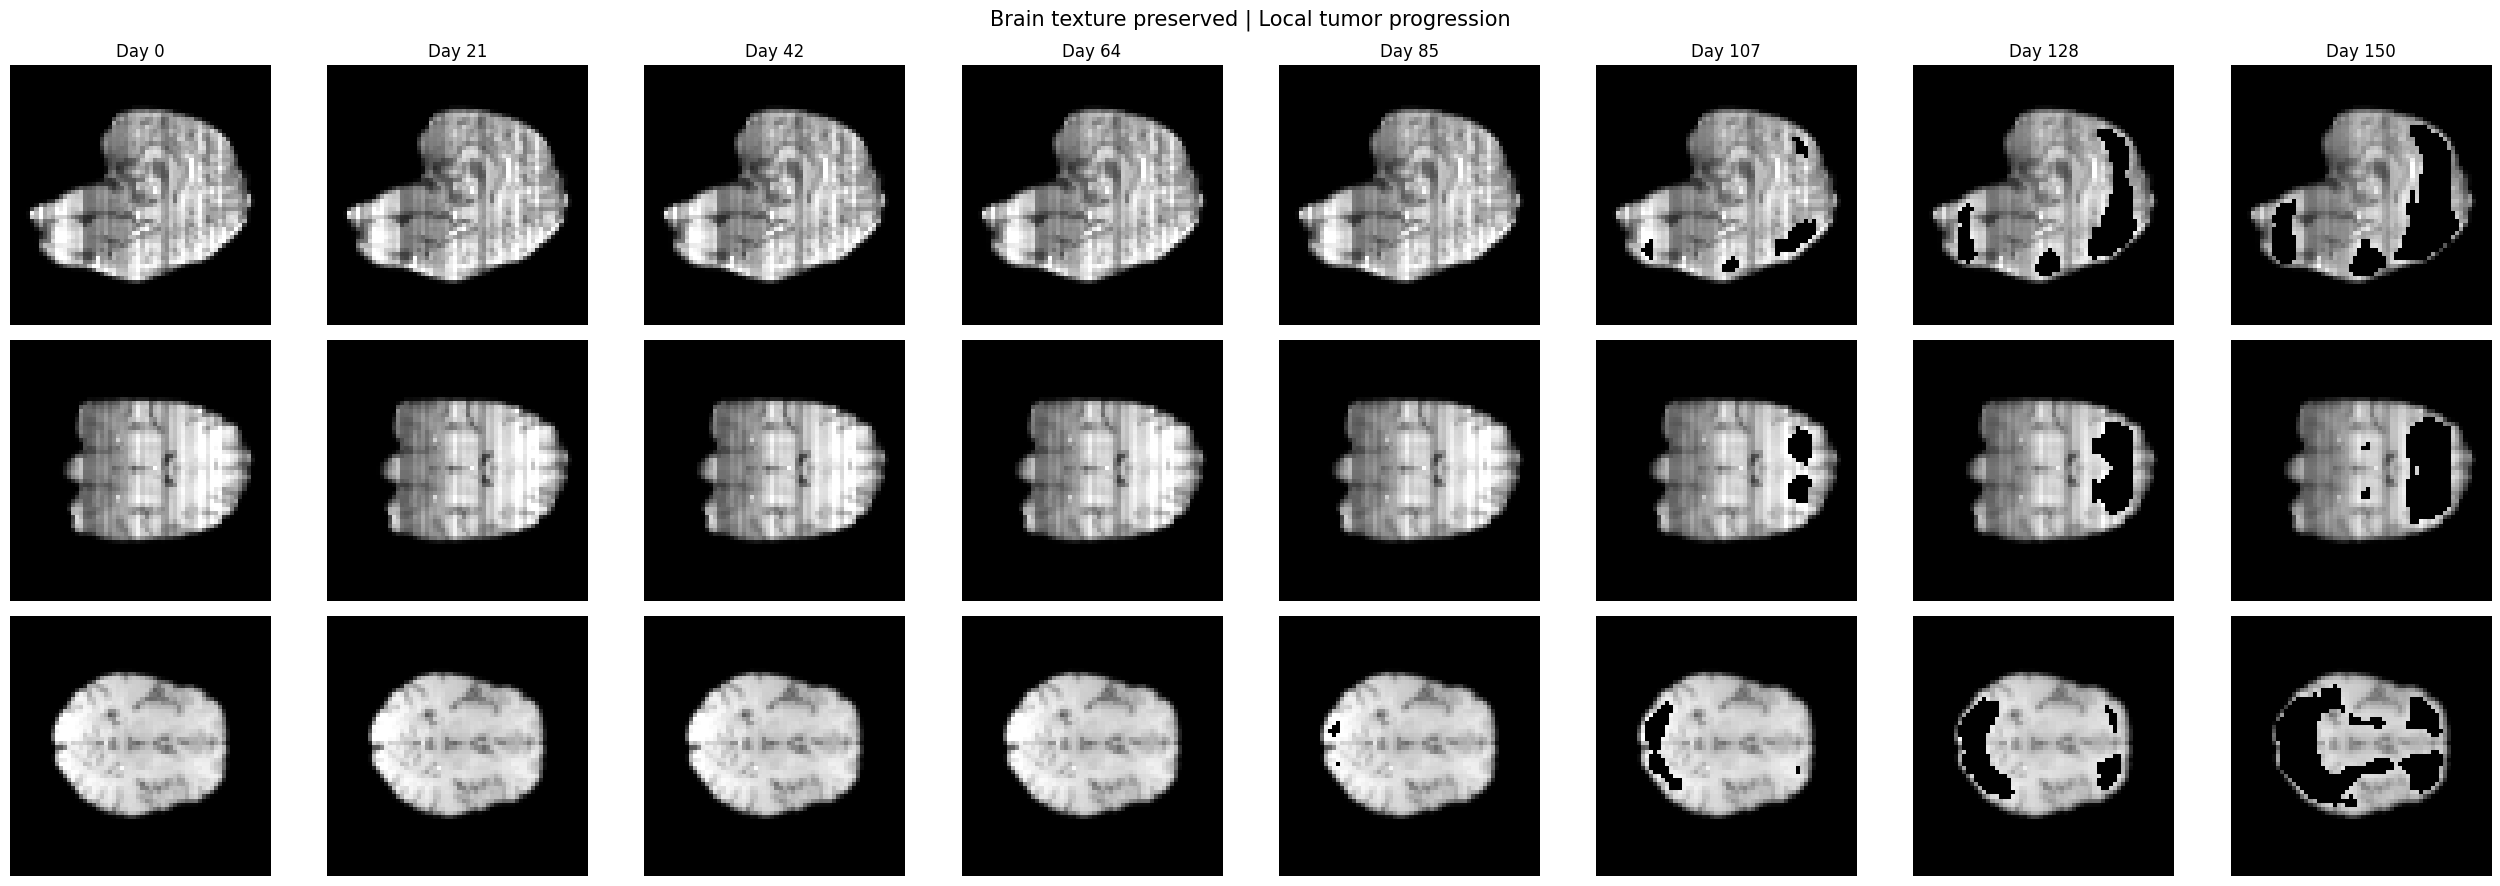

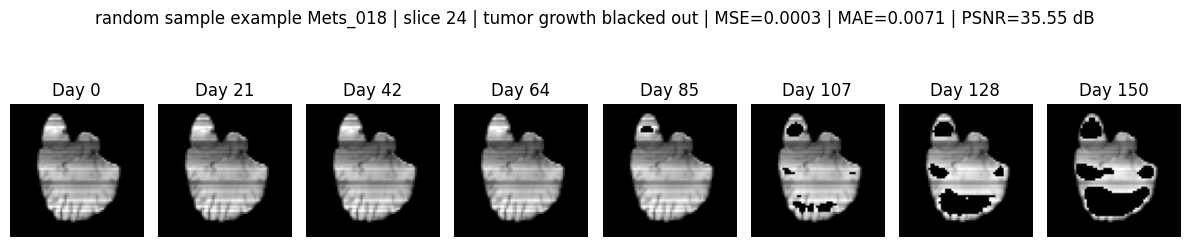

随机测试病例切片去噪、肿瘤区域涂黑与结构保持自检通过


In [18]:
# 随机测试病例切片：未来扩散预测
PREDICT_DAYS = 150 # 只需修改这里，例如改成 10 即生成 Day 0 到 Day 10
AUTO_TRAIN_DIT_IF_NEEDED = True
assert isinstance(PREDICT_DAYS, int) and PREDICT_DAYS >= 0

_test_cases = _case_dirs(TEST_ROOT)
if not _test_cases:
    raise ValueError(f'{TEST_ROOT} 中没有可用测试病例')
_real_case = random.choice(_test_cases)
_real_volume = _load_inference_volume(_real_case)
_real_slice_index = _select_informative_slice(_real_volume)
print(f'本次随机测试病例: {_real_case.name} | 推理切片: {_real_slice_index}')

# 首次切换到 DiT 时，旧 U-Net checkpoint 不能直接加载；自动重新训练并覆盖旧 checkpoint。
_checkpoint_path = NOTEBOOK_DIR / 'brain_tumor_ldm.pt'
_checkpoint = torch.load(_checkpoint_path, map_location='cpu', weights_only=True) if _checkpoint_path.exists() else {}
_checkpoint_state = _checkpoint.get('unet', {})
_checkpoint_is_dit = (
    _checkpoint.get('model_type') == 'DiT3D'
    or 'patch_embed.weight' in _checkpoint_state
)
if AUTO_TRAIN_DIT_IF_NEEDED and not _checkpoint_is_dit:
    print('检测到旧版 U-Net checkpoint，开始重新训练 DiT checkpoint...')
    vae, unet, history, test_metrics = train(TRAIN_ROOT, TEST_ROOT)

# 保持原有3D扩散预测，仅随机展示一个测试病例切片。
_real_sequence, _real_metrics = predict_tumor_progression(
    _real_case,
    predict_delta_days=PREDICT_DAYS,
    change_strength=0.35,
)
_random_slice_sequence = _real_sequence[:, 0, :, :, _real_slice_index]
_source_slice = _real_volume[0, :, :, _real_slice_index].cpu()
_target_slice = _real_sequence[-1, 0, :, :, _real_slice_index]
_slice_mse = F.mse_loss(_target_slice, _source_slice).item()
_slice_mae = F.l1_loss(_target_slice, _source_slice).item()
_slice_psnr = float('inf') if _slice_mse == 0 else -10.0 * np.log10(_slice_mse)
_display_sequence = _normalize_slice_sequence(_random_slice_sequence)
_blackout_sequence = _blackout_tumor_growth(_real_sequence)
_blackout_slice_sequence = _blackout_sequence[:, 0, :, :, _real_slice_index]
_blackout_display_sequence = _normalize_slice_sequence(_blackout_slice_sequence)
print(f'随机测试切片推理输出: {tuple(_random_slice_sequence.shape)} | 预测天数: {PREDICT_DAYS}')
print(f'MSE: {_slice_mse:.8f}')
print(f'MAE: {_slice_mae:.8f}')
print(f'PSNR: {_slice_psnr:.4f} dB')
print(
    f"结构指标 | 脑轮廓 soft IoU: {_real_metrics['contour_iou']:.6f} | "
    f"纹理相关性: {_real_metrics['texture_correlation']:.6f} | "
    f"病变区均值变化: {_real_metrics['lesion_mean_change']:+.6f}"
)
assert tuple(_real_sequence.shape) == (PREDICT_DAYS + 1, 1, *IMG_SIZE)
assert tuple(_random_slice_sequence.shape) == (PREDICT_DAYS + 1, IMG_SIZE[0], IMG_SIZE[1])
assert tuple(_blackout_slice_sequence.shape) == (PREDICT_DAYS + 1, IMG_SIZE[0], IMG_SIZE[1])
assert torch.isfinite(_real_sequence).all()
assert np.isfinite(_slice_mse) and np.isfinite(_slice_mae) and np.isfinite(_slice_psnr)
assert _real_metrics['contour_iou'] > 0.95
assert _real_metrics['texture_correlation'] > 0.90
plot_full_progression(
    _blackout_sequence,
    days=list(range(PREDICT_DAYS + 1)),
    max_steps=min(8, PREDICT_DAYS + 1),
    show_lesion_box=False,
 )
plt.figure(figsize=(12, 3))
selected_steps = np.linspace(0, PREDICT_DAYS, min(8, PREDICT_DAYS + 1), dtype=int)
for column, step in enumerate(selected_steps, start=1):
    plt.subplot(1, len(selected_steps), column)
    plt.imshow(_blackout_display_sequence[step].numpy(), cmap='gray', vmin=0, vmax=1)
    plt.axis('off')
    plt.title(f'Day {step}')
plt.suptitle(f'random sample example {_real_case.name} | slice {_real_slice_index} | tumor growth blacked out | MSE={_slice_mse:.4f} | MAE={_slice_mae:.4f} | PSNR={_slice_psnr:.2f} dB')
plt.tight_layout()
plt.show()
print('随机测试病例切片去噪、肿瘤区域涂黑与结构保持自检通过')


In [ ]:
# ====================== 9. DeepSeek 进展分析报告（可选分支） ======================
# 把上面的定量预测结果交给 DeepSeek 的 OpenAI 兼容接口(/chat/completions), 生成一段结构化中文分析。
# 只依赖标准库 urllib, 不引入新依赖; 未配置 API key、断网或接口报错时只提示并跳过, 不影响预测结果。
# API key 读取顺序: 参数 > DEEPSEEK_API_KEY 常量 > 环境变量 > ~/Desktop/deepseek_key.txt。
import json
import urllib.error
import urllib.request

DEEPSEEK_ENABLED = True
DEEPSEEK_API_KEY = os.environ.get('DEEPSEEK_API_KEY', '')   # 也可直接填 'sk-...'
DEEPSEEK_KEY_FILE = NOTEBOOK_DIR / 'deepseek_key.txt'       # 从 Finder 启动 Jupyter 时环境变量可能读不到, 可把 key 存到这里
DEEPSEEK_BASE_URL = 'https://api.deepseek.com/v1'
DEEPSEEK_MODEL = 'deepseek-chat'        # 可换成 'deepseek-reasoner'
DEEPSEEK_TEMPERATURE = 0.3
DEEPSEEK_MAX_TOKENS = 1200
DEEPSEEK_TIMEOUT_SECONDS = 60
DEEPSEEK_REPORT_DIR = NOTEBOOK_DIR / 'tumor_sim_out'


def deepseek_chat(messages, model=DEEPSEEK_MODEL, temperature=DEEPSEEK_TEMPERATURE,
                  max_tokens=DEEPSEEK_MAX_TOKENS, timeout=DEEPSEEK_TIMEOUT_SECONDS, api_key=None):
    """调用 DeepSeek 的 /chat/completions 接口, 返回助手回复文本。"""
    key = api_key or DEEPSEEK_API_KEY or os.environ.get('DEEPSEEK_API_KEY', '')
    if not key and DEEPSEEK_KEY_FILE.exists():
        key = DEEPSEEK_KEY_FILE.read_text(encoding='utf-8').strip()
    if not key:
        raise RuntimeError(f'未检测到 DeepSeek API key (环境变量 DEEPSEEK_API_KEY 或文件 {DEEPSEEK_KEY_FILE})')
    payload = json.dumps({
        'model': model,
        'messages': messages,
        'temperature': float(temperature),
        'max_tokens': int(max_tokens),
        'stream': False,
    }).encode('utf-8')
    request = urllib.request.Request(
        f'{DEEPSEEK_BASE_URL.rstrip("/")}/chat/completions',
        data=payload,
        headers={'Content-Type': 'application/json', 'Authorization': f'Bearer {key}'},
        method='POST',
    )
    try:
        with urllib.request.urlopen(request, timeout=float(timeout)) as response:
            body = json.loads(response.read().decode('utf-8'))
    except urllib.error.HTTPError as error:
        detail = error.read().decode('utf-8', errors='ignore')[:300]
        raise RuntimeError(f'DeepSeek 接口返回 HTTP {error.code}: {detail}') from error
    except urllib.error.URLError as error:
        raise RuntimeError(f'DeepSeek 接口网络不可达: {error.reason}') from error
    choices = body.get('choices') or []
    if not choices:
        raise RuntimeError(f'DeepSeek 返回内容缺少 choices 字段: {str(body)[:200]}')
    return str(choices[0].get('message', {}).get('content', '')).strip()


def _sample_day_values(values, days, count=6):
    """把逐日数值抽样成 'Day 0=0.000, ...' 形式的短串, 避免提示词过长。"""
    values = np.asarray(values, dtype=np.float64).reshape(-1)
    indices = np.unique(np.linspace(0, min(days, values.shape[0] - 1), min(count, values.shape[0])).astype(int))
    return ', '.join(f'Day{int(i)}={values[int(i)]:.3f}' for i in indices)


def build_progression_prompt(sequence, metrics, case_name, days, slice_metrics=None):
    """把预测结果整理成 DeepSeek 提示词; 只提交定量指标, 不提交影像数据。"""
    growth = metrics.get('growth_report', {}) or {}
    weights = growth.get('weights') or []
    slice_metrics = slice_metrics or {}
    facts = [
        f'病例编号: {case_name}',
        f'预测跨度: {days} 天 (Day 0 为输入影像, Day {days} 为扩散模型生成的终点)',
        f"生长律: {growth.get('law', 'exponential')} | 进度空间: {growth.get('space', 'volume')} | "
        f"等效体积倍增时间 T_d: {float(growth.get('doubling_time_days', float('nan'))):.1f} 天 | "
        f"V(N)/V(0): {float(growth.get('volume_ratio', float('nan'))):.3f}",
        f"时间权重与线性对照的最大偏差: {float(growth.get('max_abs_deviation_from_linear', float('nan'))):.4f}",
        f"结构保持指标: 脑轮廓 soft IoU={metrics.get('contour_iou', float('nan')):.4f}, "
        f"高频纹理相关性={metrics.get('texture_correlation', float('nan')):.4f}, "
        f"候选病灶区均值变化={metrics.get('lesion_mean_change', float('nan')):+.4f}",
    ]
    if weights:
        facts.append('逐日插值权重抽样: ' + _sample_day_values(weights, days))
    if slice_metrics:
        facts.append('展示切片重建误差: ' + ', '.join(
            f'{name}={float(value):.4f}' for name, value in slice_metrics.items()))
    system = (
        '你是医学影像研究助理, 负责把生成模型的定量输出改写成结构化的中文分析。要求: '
        '(1) 只依据给定数值, 不编造未提供的数字或结论; (2) 不做临床诊断、不给治疗建议; '
        '(3) 按"预测设置 / 时间推进 / 结构保持 / 局限性"四段输出, 每段 2-4 句; '
        '(4) 明确指出中间帧是按生长律非均匀插值得到的生成结果, 不代表真实随访。'
    )
    user = '以下是本次脑转移瘤进展模拟的定量结果, 请据此撰写分析:\n' + '\n'.join(f'- {item}' for item in facts)
    return [{'role': 'system', 'content': system}, {'role': 'user', 'content': user}]


def generate_progression_report(sequence, metrics, case_name, days, slice_metrics=None,
                                save=True, verbose=True):
    """调用 DeepSeek 生成分析报告; 返回文本(None 表示已跳过)。任何异常都只提示, 不中断 notebook。"""
    if not DEEPSEEK_ENABLED:
        print('DeepSeek 分析未启用 (DEEPSEEK_ENABLED=False)')
        return None
    try:
        messages = build_progression_prompt(sequence, metrics, case_name, days, slice_metrics)
        report = deepseek_chat(messages)
    except Exception as error:
        print(f'DeepSeek 分析已跳过: {error}')
        return None
    if verbose:
        print(f'===== DeepSeek({DEEPSEEK_MODEL}) 进展分析 =====')
        print(report)
    if save:
        try:
            DEEPSEEK_REPORT_DIR.mkdir(parents=True, exist_ok=True)
            report_path = DEEPSEEK_REPORT_DIR / f'deepseek_report_{case_name}_day{days}.md'
            report_path.write_text(report + '\n', encoding='utf-8')
            print(f'报告已保存: {report_path}')
        except OSError as error:
            print(f'报告保存失败(不影响结果): {error}')
    return report


_deepseek_report = generate_progression_report(
    _real_sequence,
    _real_metrics,
    _real_case.name,
    PREDICT_DAYS,
    slice_metrics={'MSE': _slice_mse, 'MAE': _slice_mae, 'PSNR_dB': _slice_psnr},
)
